   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 29.9 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 41.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 34.4 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 31.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 37.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]


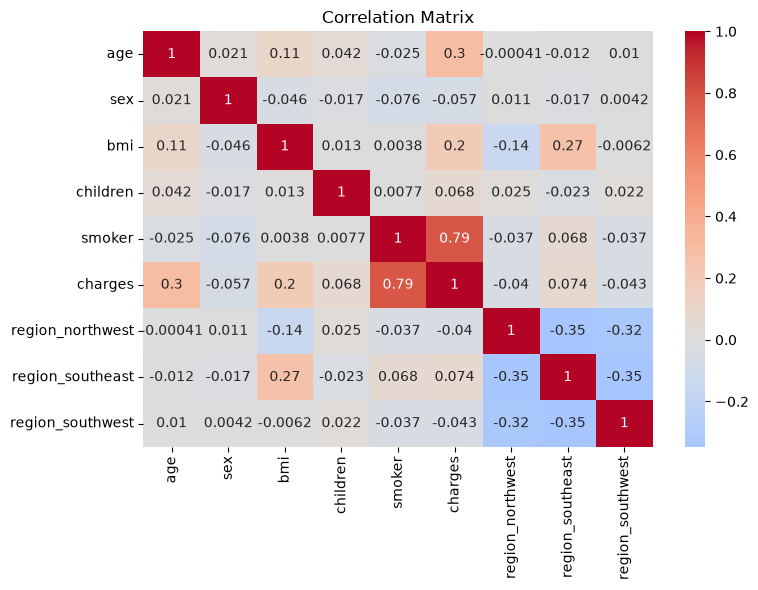

In [ ]:
    !pip install pandas
    !pip install seaborn
    !pip install matplotlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("insurance.csv")

# quick numeric encoding just for the correlation matrix
corr_df = df.copy()
corr_df['sex'] = corr_df['sex'].map({'male': 0, 'female': 1})
corr_df['smoker'] = corr_df['smoker'].map({'no': 0, 'yes': 1})
corr_df = pd.get_dummies(corr_df, columns=['region'], drop_first=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

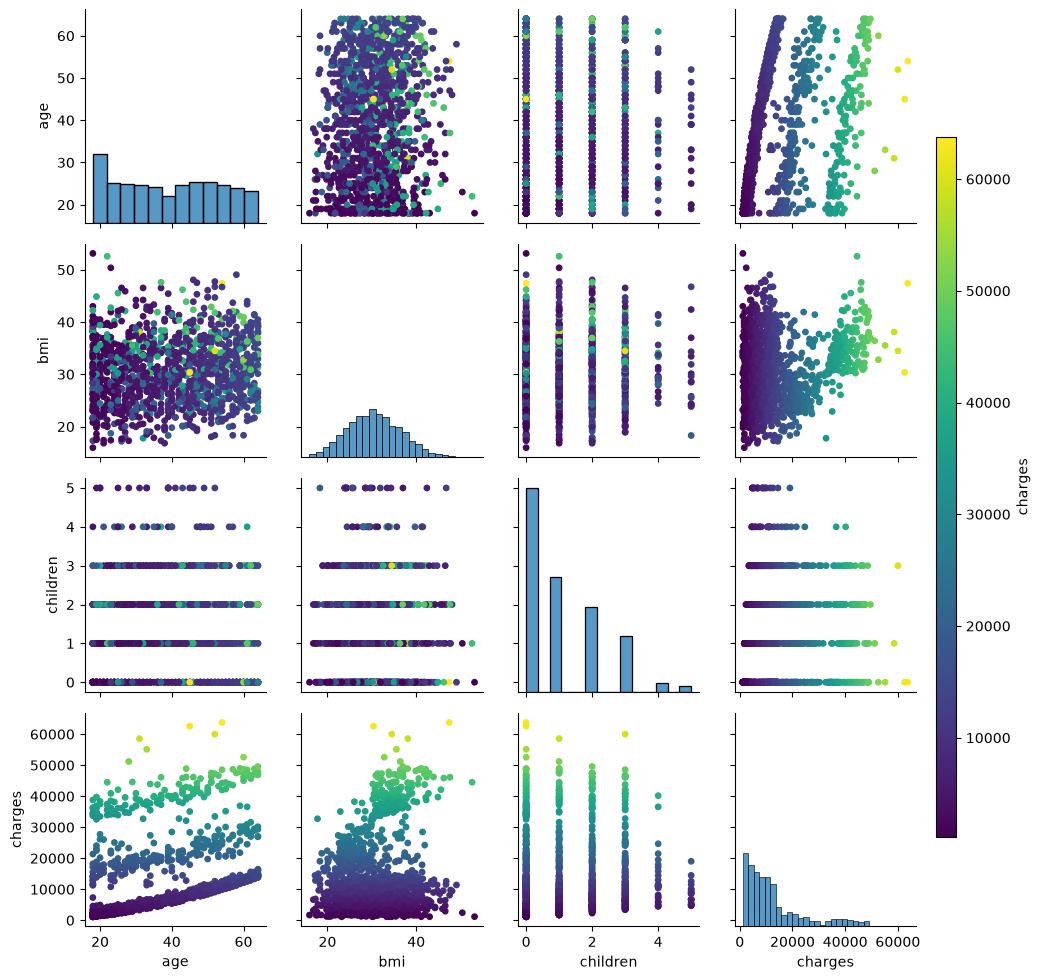

In [4]:
import numpy as np

vars_to_plot = ['age', 'bmi', 'children', 'charges']
g = sns.PairGrid(df, vars=vars_to_plot)
g.map_offdiag(lambda x, y, **kws: plt.scatter(x, y, c=df['charges'], cmap='viridis', s=15))
g.map_diag(sns.histplot)

# add a colorbar
plt.gcf().subplots_adjust(right=0.9)
cbar_ax = plt.gcf().add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(df['charges'].min(), df['charges'].max()))
plt.gcf().colorbar(sm, cax=cbar_ax, label='charges')

plt.show()

In [ ]:
!pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# select continuous predictors and add a constant (required for VIF to work correctly)
cont = df[['age', 'bmi', 'children']]
cont_sm = sm.add_constant(cont)

vif_data = pd.DataFrame()
vif_data['variable'] = cont_sm.columns
vif_data['VIF'] = [variance_inflation_factor(cont_sm.values, i) for i in range(cont_sm.shape[1])]

print(vif_data)

# essentially no multicollinearity between the numeric variables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 36.8 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 37.7 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [statsmodels] [statsmodels]
   variable       VIF
0     const  1.000000
1       age  1.013816
2       bmi  1.012152
3  children  1.001874


In [7]:

# ---------- 1. Baseline model: continuous + categorical ----------
X = pd.get_dummies(df.drop(columns='charges'), drop_first=True)  # remove charges (our target), turn text columns into 0/1 columns
X = X.astype(float)  # make sure every column is a number
X_sm = sm.add_constant(X)  # add a column of 1s so the model can calculate an intercept

baseline = sm.OLS(df['charges'], X_sm).fit()  # run the regression: predict charges using X_sm
print("BASELINE")  # label for the output
print(f"R²={baseline.rsquared:.4f}, Adj R²={baseline.rsquared_adj:.4f}\n")  # print how well the model fits (R² and adjusted R²)

# ---------- 2. Interaction: smoker x bmi ----------
X['smoker_bmi'] = X['smoker_yes'] * df['bmi']  # new column: bmi for smokers, 0 for non-smokers
X_sm2 = sm.add_constant(X)  # re-add the constant column now that X has a new column

model_smoker_bmi = sm.OLS(df['charges'], X_sm2).fit()  # re-run the regression with the new column included
print("BASELINE + smoker x bmi")  # label for the output
print(f"R²={model_smoker_bmi.rsquared:.4f}, Adj R²={model_smoker_bmi.rsquared_adj:.4f}\n")  # print the new fit scores

# ---------- 4. Polynomial: age^2 (centered first) ----------
X['age_sq'] = df['age']**2  # new column: centered age squared (lets the model curve)
X_sm4 = sm.add_constant(X)  # re-add the constant column again

model_full = sm.OLS(df['charges'], X_sm4).fit()  # re-run the regression with everything included
print("FULL MODEL (+ age^2)")  # label for the output
print(f"R²={model_full.rsquared:.4f}, Adj R²={model_full.rsquared_adj:.4f}\n")  # print the final fit scores

# ---------- 5. VIF on the full model ----------
vif_data = pd.DataFrame()  # create an empty table to hold the VIF results
vif_data['variable'] = X_sm4.columns  # first column of the table: names of each variable
vif_data['VIF'] = [variance_inflation_factor(X_sm4.values, i) for i in range(X_sm4.shape[1])]  # second column: VIF score for each variable (loops through them one by one)
print("VIF (full model):")  # label for the output
print(vif_data)  # show the VIF table

# ---------- 6. Compare all models side by side ----------
comparison = pd.DataFrame({  # build a summary table
    'Model': ['Baseline', '+smoker x bmi', '+smoker x age', '+age^2 (full)'],  # names of the 4 models
    'R2': [baseline.rsquared, model_smoker_bmi.rsquared,  # R² for each model, in the same order
           model_smoker_age.rsquared, model_full.rsquared],
    'Adj_R2': [baseline.rsquared_adj, model_smoker_bmi.rsquared_adj,  # adjusted R² for each model, same order
               model_smoker_age.rsquared_adj, model_full.rsquared_adj]
})
print("\nMODEL COMPARISON")  # label for the output
print(comparison)  # show the comparison table

BASELINE
R²=0.7509, Adj R²=0.7494

BASELINE + smoker x bmi
R²=0.8409, Adj R²=0.8398

FULL MODEL (+ age^2)
R²=0.8435, Adj R²=0.8423

VIF (full model):
            variable        VIF
0              const   1.000000
1                age  47.616261
2                bmi   1.388480
3           children   1.102198
4           sex_male   1.011505
5         smoker_yes  25.205332
6   region_northwest   1.519671
7   region_southeast   1.652697
8   region_southwest   1.530439
9         smoker_bmi  25.534835
10            age_sq  47.570839

MODEL COMPARISON
           Model        R2    Adj_R2
0       Baseline  0.750913  0.749414
1  +smoker x bmi  0.840918  0.839840
2  +smoker x age  0.840919  0.839720
3  +age^2 (full)  0.843463  0.842284


In [9]:
# ================= WEEK 1 TAKEAWAYS =================

# 1. BASELINE MODEL (continuous + categorical features only)
#    - R² = 0.751, Adj R² = 0.749
#    - Explains ~75% of the variation in charges using age, bmi, children,
#      sex, smoker, and region with no polynomial/interaction terms yet

# 2. INTERACTION TERM: smoker x bmi
#    - R² jumped to 0.841, Adj R² to 0.840 (+0.09 improvement)
#    - This is the single biggest gain in the whole analysis
#    - Confirms what the EDA showed: smoking status changes how much bmi
#      matters, rather than the two acting independently on charges

# 3. INTERACTION TERM: smoker x age
#    - R² barely moved (0.840918 -> 0.840919)
#    - Adjusted R² actually went DOWN slightly (0.839840 -> 0.839720)
#    - Takeaway: this term does not earn its place in the model and
#      should likely be dropped from the final version

# 4. POLYNOMIAL TERM: age^2
#    - R² increased slightly to 0.843, Adj R² to 0.842
#    - Small but real improvement -- age's effect on charges curves a bit,
#      but nowhere near as impactful as the smoker x bmi interaction

# 5. MULTICOLLINEARITY (VIF)
#    - age and age_sq both ~47.6 -- expected, a variable and its square
#      are naturally correlated
#    - smoker_yes and smoker_bmi both ~25 -- same reason, interaction term
#      is built directly from the original variable
#    - All other variables (bmi, children, sex, region) stayed under 2,
#      so no unexpected multicollinearity elsewhere
#    - High VIF here is a normal side effect of adding polynomial/interaction
#      terms, not a flaw in the model -- centering age before squaring it
#      would reduce this if a cleaner VIF table is wanted

# 6. OVERALL CONCLUSION -- Optimal Modeling Strategy
#    - Interaction terms outperformed polynomial terms for this dataset
#    - smoker x bmi alone drove nearly the entire improvement over baseline
#    - age^2 added a small amount of value; smoker x age added none
#    - Matches the EDA: correlation matrix showed smoker was the dominant
#      driver of charges (0.79), and the scatterplot showed charges splitting
#      into distinct bands (interaction pattern) rather than one smooth curve

In [ ]:
# OTHER DATASET- CLAIMS FRAUD

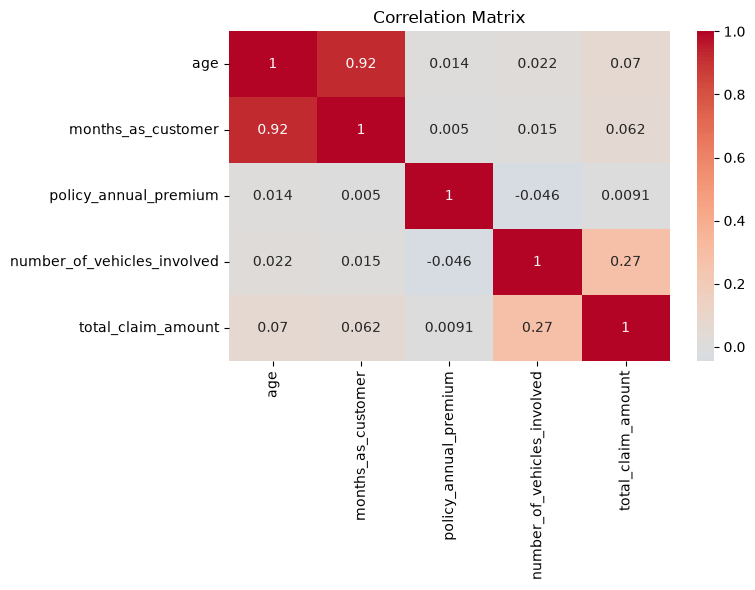

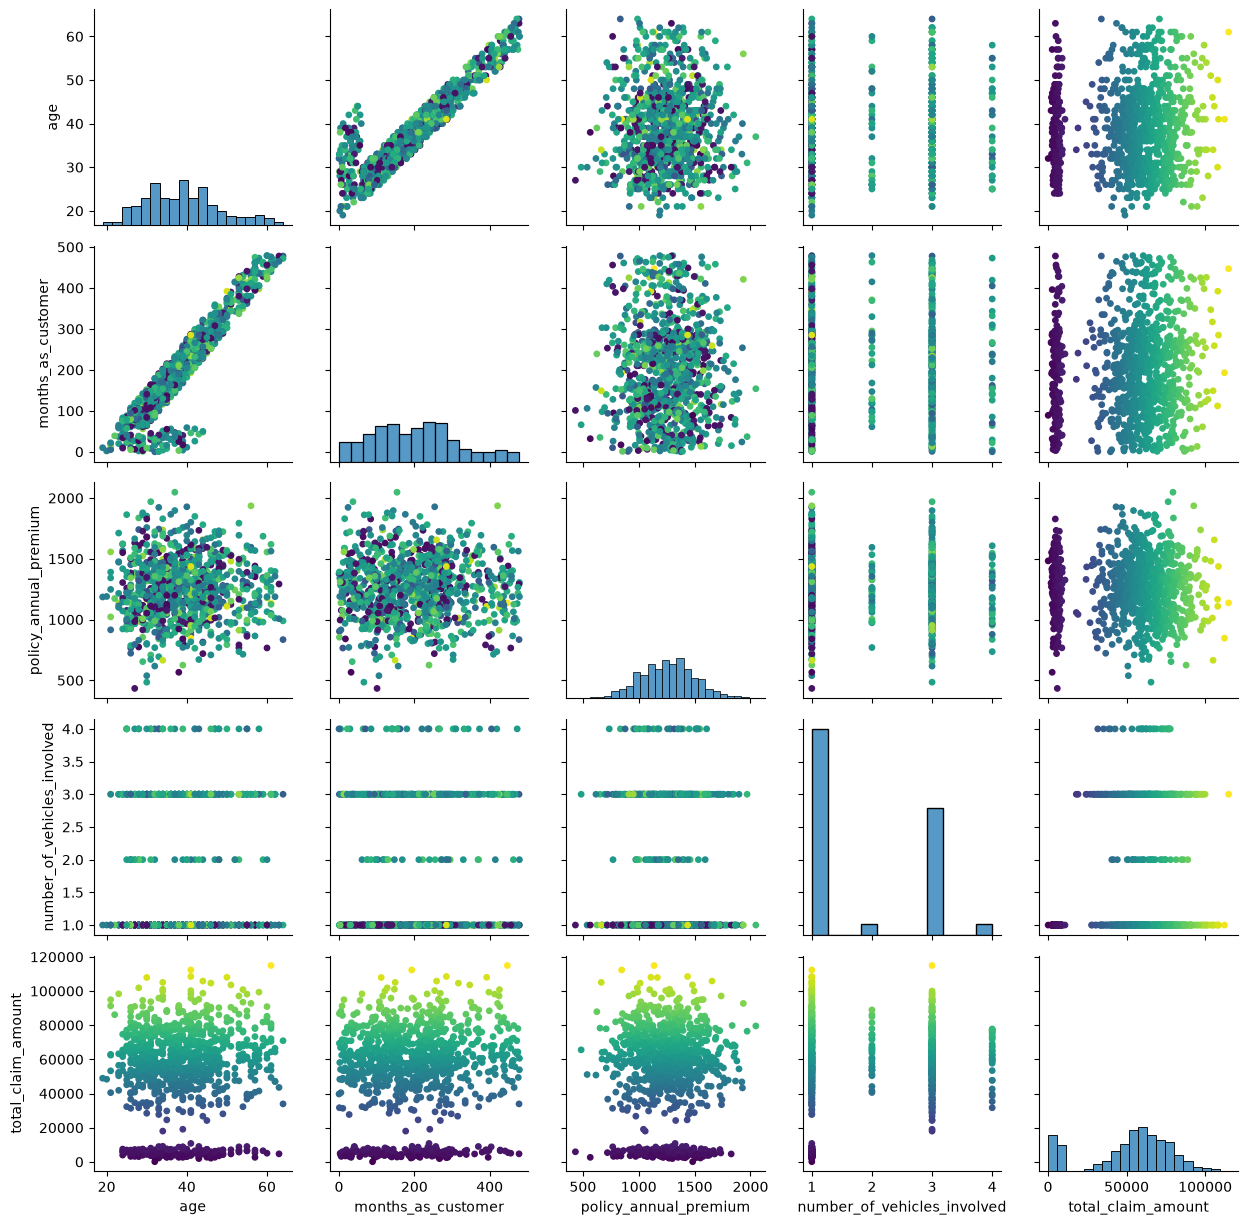

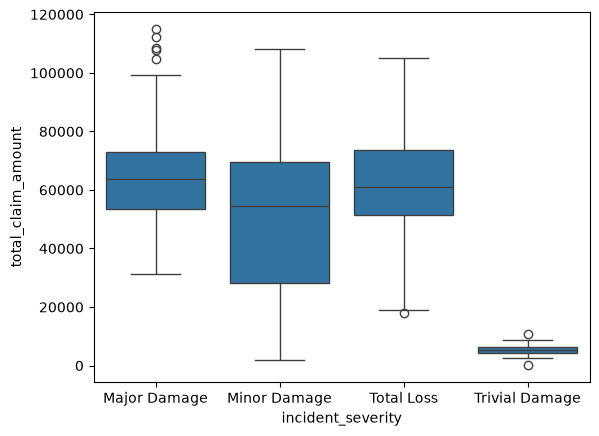

                      variable       VIF
0                        const  1.000000
1                          age  6.686345
2           months_as_customer  6.683154
3        policy_annual_premium  1.002847
4  number_of_vehicles_involved  1.002885
Index(['age', 'months_as_customer', 'policy_annual_premium',
       'number_of_vehicles_involved', 'incident_severity_Minor Damage',
       'incident_severity_Total Loss', 'incident_severity_Trivial Damage',
       'collision_type_Rear Collision', 'collision_type_Side Collision',
       'collision_type_Unknown', 'insured_sex_MALE', 'property_damage_Unknown',
       'property_damage_YES'],
      dtype='str')
BASELINE: R²=0.7048, Adj R²=0.7009
+INTERACTION: R²=0.7048, Adj R²=0.7006
+POLYNOMIAL: R²=0.7049, Adj R²=0.7004
                            variable        VIF
0                              const   1.000000
1                                age  57.637636
2                 months_as_customer   6.824684
3              policy_annual_premium   

In [1]:
import pandas as pd  # data tables
import numpy as np  # math helpers
import seaborn as sns  # plots
import matplotlib.pyplot as plt  # plots
import statsmodels.api as sm  # regression
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF check

# ---------- 1. Load and clean ----------
df = pd.read_csv("insurance_claims.csv")  # change to your file name
df = df.replace('?', 'Unknown')  # "?" means missing, so make it its own category

num_cols = ['age', 'months_as_customer', 'policy_annual_premium',
            'number_of_vehicles_involved']  # continuous predictors
cat_cols = ['incident_severity', 'collision_type', 'insured_sex', 'property_damage']  # categorical predictors
df = df[num_cols + cat_cols + ['total_claim_amount']].dropna()  # keep only the columns we need
y = df['total_claim_amount']  # target

# ---------- 2. EDA: correlation plot ----------
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols + ['total_claim_amount']].corr(), annot=True, cmap='coolwarm', center=0)  # correlation heatmap
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# ---------- 2b. EDA: scatterplot matrix, colored by total_claim_amount ----------
vars_to_plot = num_cols + ['total_claim_amount']  # variables to plot
g = sns.PairGrid(df, vars=vars_to_plot)  # grid of plots
g.map_offdiag(lambda x, z, **kws: plt.scatter(x, z, c=df['total_claim_amount'], cmap='viridis', s=15))  # color points by claim amount
g.map_diag(sns.histplot)  # histograms on the diagonal
plt.show()

# ---------- 2c. EDA: claim size by category ----------
sns.boxplot(data=df, x='incident_severity', y='total_claim_amount')  # how claims differ by severity
plt.show()

# ---------- 3. Multicollinearity: VIF on continuous predictors ----------
cont = sm.add_constant(df[num_cols])  # add constant (needed for VIF)
vif = pd.DataFrame({'variable': cont.columns,
                    'VIF': [variance_inflation_factor(cont.values, i) for i in range(cont.shape[1])]})
print(vif)  # ignore const; look at age vs months_as_customer

# ---------- 4. Baseline model (continuous + categorical) ----------
X = pd.get_dummies(df.drop(columns='total_claim_amount'), columns=cat_cols, drop_first=True).astype(float)  # text -> 0/1 columns
print(X.columns)  # check the dummy column names
baseline = sm.OLS(y, sm.add_constant(X)).fit()  # fit the baseline regression
print(f"BASELINE: R²={baseline.rsquared:.4f}, Adj R²={baseline.rsquared_adj:.4f}")

# ---------- 5. Interaction term: major damage x number of vehicles ----------
major = (df['incident_severity'] == 'Major Damage').astype(float)  # temporary 1/0 flag (not added to X on its own)
X['major_x_vehicles'] = major * df['number_of_vehicles_involved']  # interaction column
m_inter = sm.OLS(y, sm.add_constant(X)).fit()  # refit with the interaction
print(f"+INTERACTION: R²={m_inter.rsquared:.4f}, Adj R²={m_inter.rsquared_adj:.4f}")

# ---------- 6. Polynomial term: age squared ----------
X['age_sq'] = df['age']**2  # squared age (lets the model curve)
m_poly = sm.OLS(y, sm.add_constant(X)).fit()  # refit with both terms
print(f"+POLYNOMIAL: R²={m_poly.rsquared:.4f}, Adj R²={m_poly.rsquared_adj:.4f}")

# ---------- 7. VIF on the full model ----------
X_full = sm.add_constant(X)  # full feature set + constant
vif_full = pd.DataFrame({'variable': X_full.columns,
                         'VIF': [variance_inflation_factor(X_full.values, i) for i in range(X_full.shape[1])]})
print(vif_full)  # expect high VIF on age, age_sq, months_as_customer

# ---------- 8. Compare all models ----------
comparison = pd.DataFrame({
    'Model': ['Baseline', '+Interaction', '+Polynomial (full)'],  # model names
    'R2': [baseline.rsquared, m_inter.rsquared, m_poly.rsquared],  # R² for each
    'Adj_R2': [baseline.rsquared_adj, m_inter.rsquared_adj, m_poly.rsquared_adj]  # adjusted R² for each
})
print("\nMODEL COMPARISON")
print(comparison)

# ---------- 9. Optional: significance of the new terms ----------
print(m_poly.summary().tables[1])  # check p-values for major_x_vehicles and age_sq (want p < 0.05)

fraud
0    753
1    247
Name: count, dtype: int64


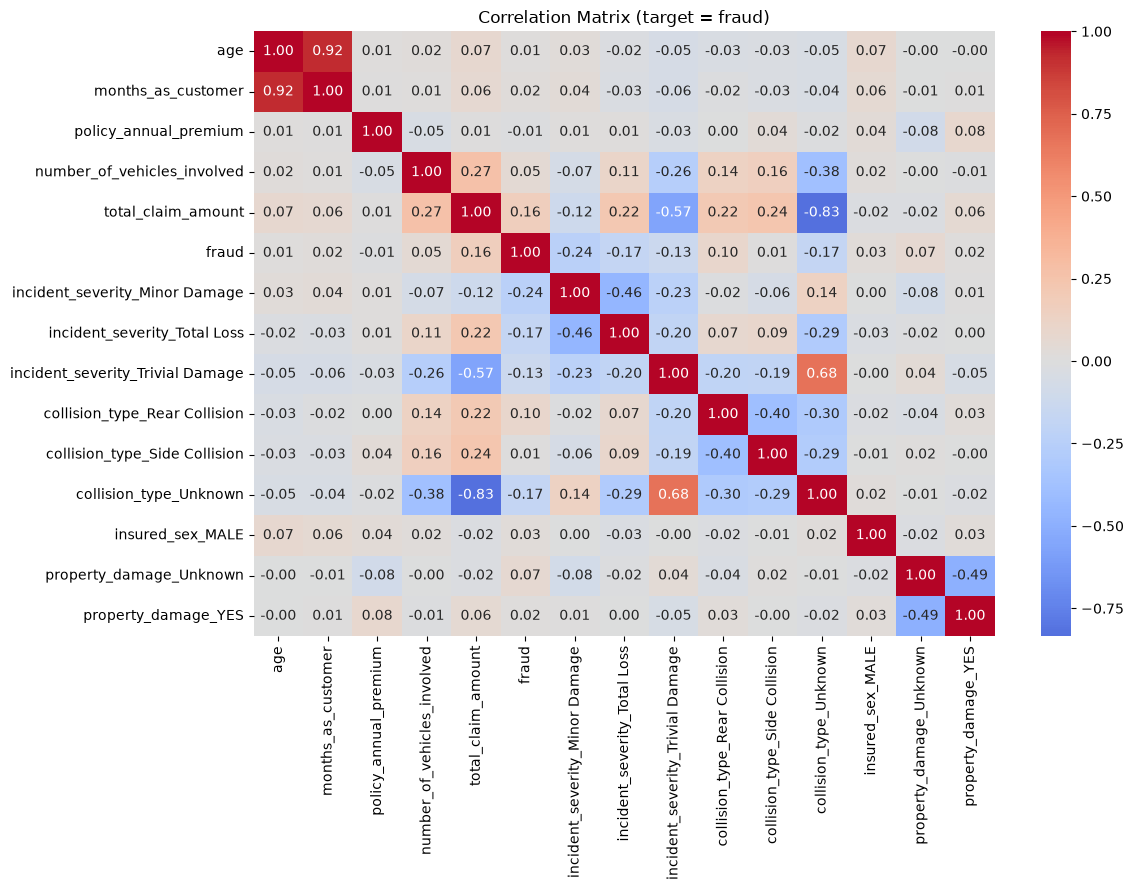

total_claim_amount                  0.164
collision_type_Rear Collision       0.096
property_damage_Unknown             0.068
number_of_vehicles_involved         0.052
insured_sex_MALE                    0.031
months_as_customer                  0.021
property_damage_YES                 0.017
age                                 0.012
collision_type_Side Collision       0.009
policy_annual_premium              -0.014
incident_severity_Trivial Damage   -0.132
collision_type_Unknown             -0.170
incident_severity_Total Loss       -0.171
incident_severity_Minor Damage     -0.240
Name: fraud, dtype: float64


In [2]:

df = pd.read_csv("insurance_claims.csv")  # load the data
df = df.replace('?', 'Unknown')  # "?" means missing, so make it its own category

# ---------- Turn the target into 1 and 0 ----------
df['fraud'] = df['fraud_reported'].map({'Y': 1, 'N': 0})  # Y -> 1, N -> 0
print(df['fraud'].value_counts())  # check how many frauds vs. non-frauds

# ---------- Pick columns and make everything numeric ----------
num_cols = ['age', 'months_as_customer', 'policy_annual_premium',
            'number_of_vehicles_involved', 'total_claim_amount']  # continuous columns (claim amount is now a predictor)
cat_cols = ['incident_severity', 'collision_type', 'insured_sex', 'property_damage']  # categorical columns

corr_df = df[num_cols + cat_cols + ['fraud']]  # keep only what we need
corr_df = pd.get_dummies(corr_df, columns=cat_cols, drop_first=True).astype(float)  # text -> 0/1 columns

# ---------- Correlation plot ----------
plt.figure(figsize=(12, 9))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)  # heatmap of all correlations
plt.title("Correlation Matrix (target = fraud)")
plt.tight_layout()
plt.show()

# ---------- Easier to read: correlation with fraud only ----------
print(corr_df.corr()['fraud'].drop('fraud').sort_values(ascending=False).round(3))  # strongest to weakest

In [ ]:
x

In [ ]:
# ================= CORRELATION TAKEAWAYS: target = fraud (1 = fraud, 0 = not fraud) =================

# 1. CORRELATIONS WITH FRAUD (the "fraud" row)
#    - Everything is weak: the strongest is only -0.24. That is normal for a 0/1 target
#    - incident_severity_Minor Damage = -0.24: strongest signal in the plot
#    - incident_severity_Total Loss = -0.17 and Trivial Damage = -0.13
#    - Important: "Major Damage" is the reference group (it was dropped by get_dummies), so these negatives
#      mean Major Damage claims are MORE likely to be fraud than the other severity types
#    - collision_type_Unknown = -0.17: claims with no collision (likely theft/parked car) are less often fraud
#    - collision_type_Rear Collision = +0.10: slightly more fraud than the reference group (Front Collision)
#    - total_claim_amount = +0.16: bigger claims are slightly more likely to be fraud
#    - age (0.01), months_as_customer (0.02), policy_annual_premium (-0.01), insured_sex (0.03):
#      basically no relationship with fraud, so these are unlikely to help even with polynomial terms

# 2. MULTICOLLINEARITY AMONG PREDICTORS (this is the week 1 concept)
#    - age vs months_as_customer = 0.92: same overlap we saw before, still the clearest VIF problem
#    - total_claim_amount vs collision_type_Unknown = -0.83: very high. These two carry a lot of the
#      same information (no-collision claims are tiny)
#    - collision_type_Unknown vs Trivial Damage = 0.68: also overlapping (small, no-collision incidents)
#    - total_claim_amount vs Trivial Damage = -0.57: same story
#    - Takeaway: total_claim_amount, collision_type, and incident_severity are all describing the same
#      thing (small vs. large incidents), so expect high VIFs if all are in one model

# 3. WHAT THIS SUGGESTS FOR THE MODELING STRATEGY
#    - Continuous features (age, months_as_customer, premium) show no signal, so polynomial terms on them
#      are unlikely to help
#    - The signal is in severity and claim size, so an interaction between them is the best candidate
#      (e.g., does claim size matter more for Major Damage claims?)
#    - To reduce multicollinearity: drop months_as_customer (keep age), and consider keeping only one of
#      collision_type or incident_severity
#    - Limitation to mention in the write-up: linear regression on a 0/1 target (a "linear probability
#      model") can predict values below 0 or above 1. Logistic regression is the better tool for later weeks